Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


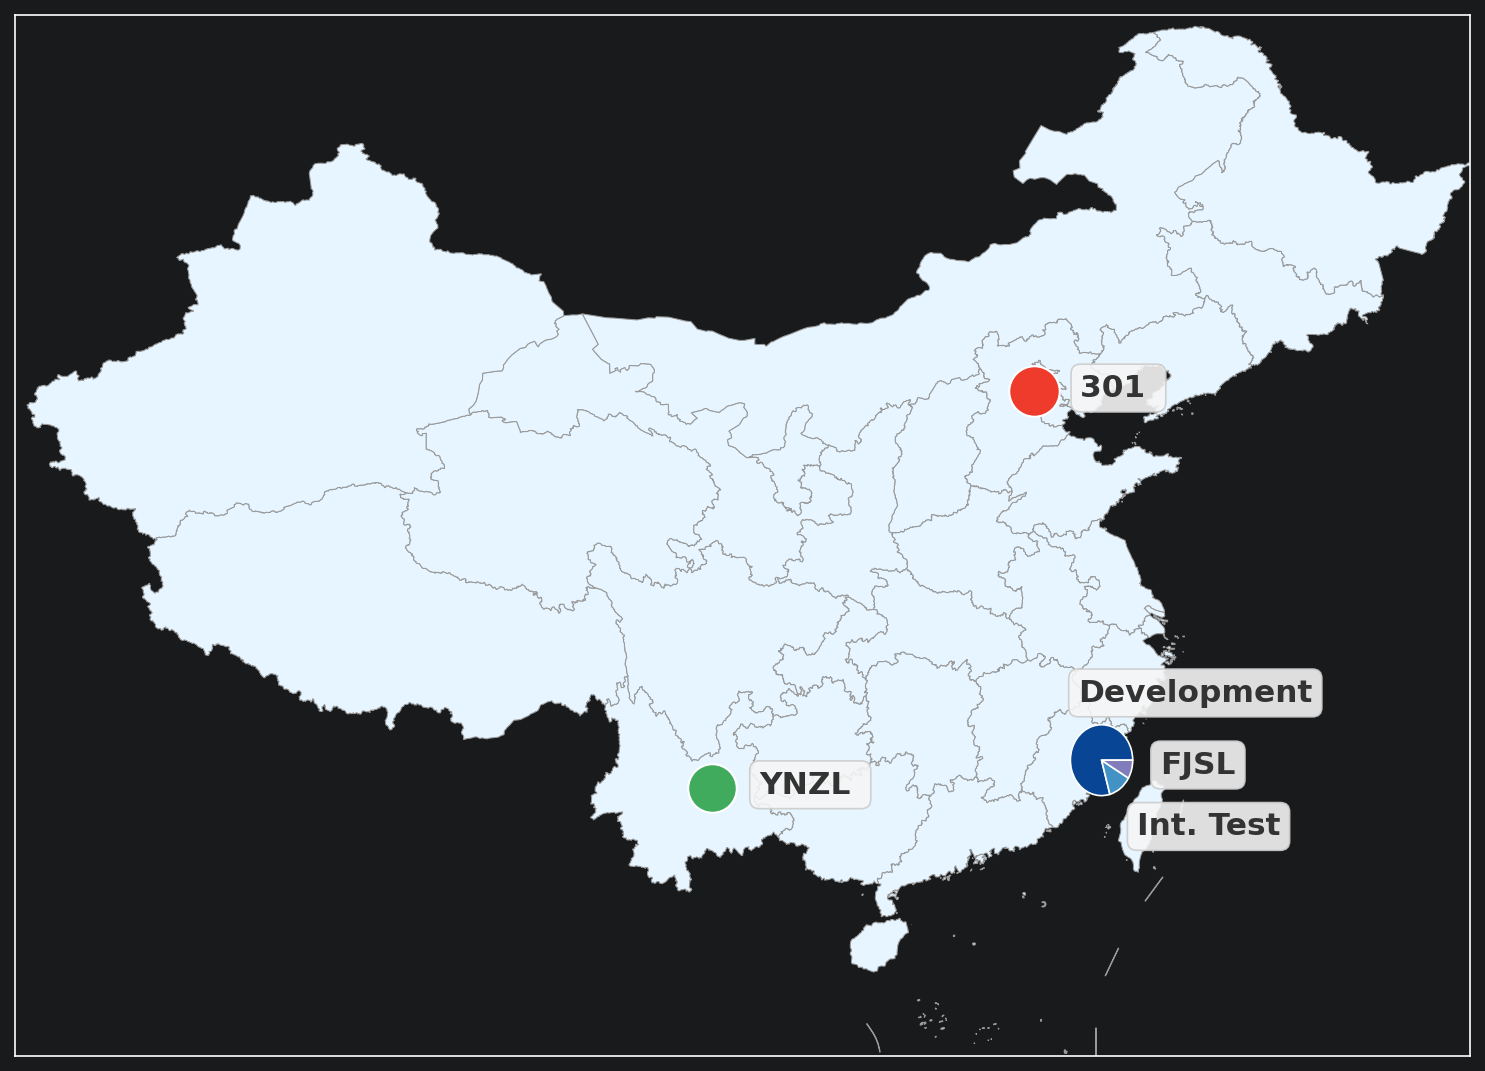

In [1]:
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import requests

def draw_pie(ax, lon, lat, counts, colors, radius=1.25):
    angles = np.r_[0, np.cumsum(np.array(counts) / sum(counts) * 360)]
    for i, color in enumerate(colors):
        ax.add_patch(Wedge(
            (lon, lat), radius, angles[i], angles[i + 1],
            facecolor=color, edgecolor="white", linewidth=1, zorder=5
        ))

path = "china_map.json"
if not os.path.exists(path):
    r = requests.get("https://geo.datav.aliyun.com/areas_v3/bound/100000_full.json", timeout=30)
    open(path, "w", encoding="utf-8").write(r.text)

china = gpd.read_file(path)

colors = {
    "Maixin": "#084594",
    "FJSL": "#807dba",
    "301": "#ef3b2c",
    "YNZL": "#41ab5d"
}

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=150)
china.plot(ax=ax, facecolor="#e6f5ff", edgecolor="#999999", linewidth=0.5)

# 福州：Maixin(Dev.+Int.Test) + FJSL
draw_pie(
    ax, 119.30, 26.08,
    [2235 + 345, 238],
    [colors["Maixin"], colors["FJSL"]]
)

# 福州标签
ax.text(
    118.2, 28.2, "Maixin",
    fontsize=15, weight="bold", color="#333333",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#cccccc", alpha=0.9),
    zorder=6
)
ax.text(
    121.0, 25.8, "FJSL",
    fontsize=15, weight="bold", color="#333333",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#cccccc", alpha=0.9),
    zorder=6
)

# 301 和 YNZL
points = {
    "301": (116.40, 39.90, 1.8, 0.0),
    "YNZL": (102.71, 25.04, 1.8, 0.0)
}
for name, (lon, lat, dx, dy) in points.items():
    ax.scatter(lon, lat, s=260, color=colors[name], edgecolors="white", linewidth=1, zorder=5)
    ax.text(
        lon + dx, lat + dy, name,
        fontsize=15, weight="bold", color="#333333",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#cccccc", alpha=0.9),
        zorder=6
    )

ax.set(xlim=(73, 135), ylim=(15, 54), xticks=[], yticks=[])
ax.set_aspect(1 / np.cos(np.deg2rad(35)))

plt.tight_layout()
os.makedirs("cohort", exist_ok=True)
plt.savefig("cohort/datamap.svg", bbox_inches="tight", transparent=True)
plt.show()

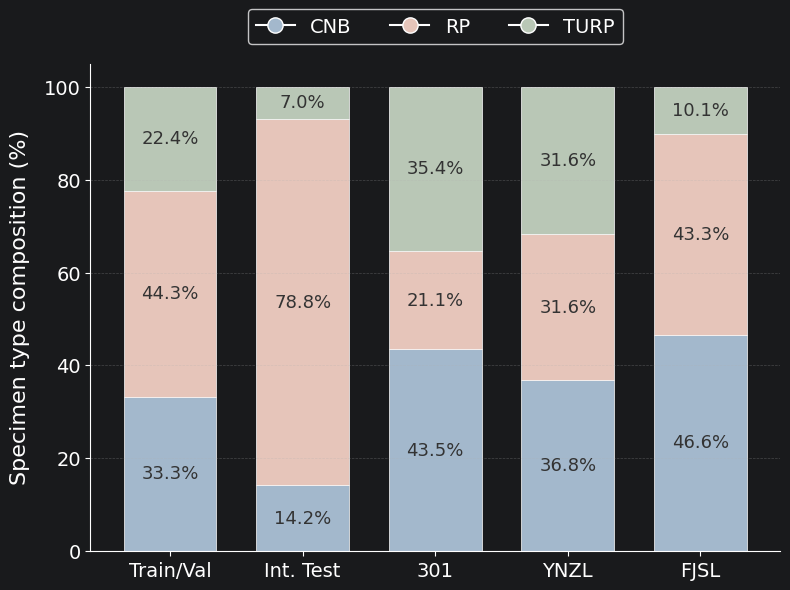

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# 1. 极简数据准备与比例计算
df = pd.DataFrame({ 'Center': ['Train/Val', 'Int. Test', '301', 'YNZL', 'FJSL'],
                    'CNB': [744, 49, 64, 50, 111],
                    'RP': [990, 272, 31, 43, 103],
                    'TURP': [501, 24, 52, 43, 24] }).set_index('Center')
df_perc = df.div(df.sum(axis=1), axis=0) * 100

# 2. 统一配置（基准大字号与色彩）
FS = 14
colors = ['#A3B8CC', '#E6C5BA', '#B9C7B6']

# 3. 一键绘图（直接在plot中集成 figsize, rot=0 轴不旋转, xlabel为空）
ax = df_perc.plot(kind='bar', stacked=True, figsize=(8, 6), color=colors, width=0.7, edgecolor='white', lw=0.5, rot=0, xlabel='')

# 4. 堆叠图百分比标注（字号放大至 11）
for p in ax.patches:
    w, h = p.get_width(), p.get_height()
    if h > 5:
        ax.text(p.get_x() + w / 2, p.get_y() + h / 2, f'{h:.1f}%', ha='center', va='center', fontsize=FS-1, color='#333333')

# 5. 轴样式与网格美化（刻度字号 12，标签字号 14）
ax.set_ylabel('Specimen type composition (%)', fontsize=FS+2, labelpad=10,)
ax.tick_params(labelsize=FS)
ax.spines[['top', 'right']].set_visible(False) # 现代matplotlib支持批量隐藏边框
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 6. 列表推导式一行重构自定义圆点图例（自动读取df.columns，字号放大至 12）
handles = [Line2D([0], [0], marker='o', color='w', mfc=c, ms=11, label=l) for c, l in zip(colors, df.columns)]
ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True, fontsize=FS, edgecolor='#F0F0F0')

plt.tight_layout()
plt.savefig('cohort/Specimen.svg', dpi=300, bbox_inches='tight')
plt.show()

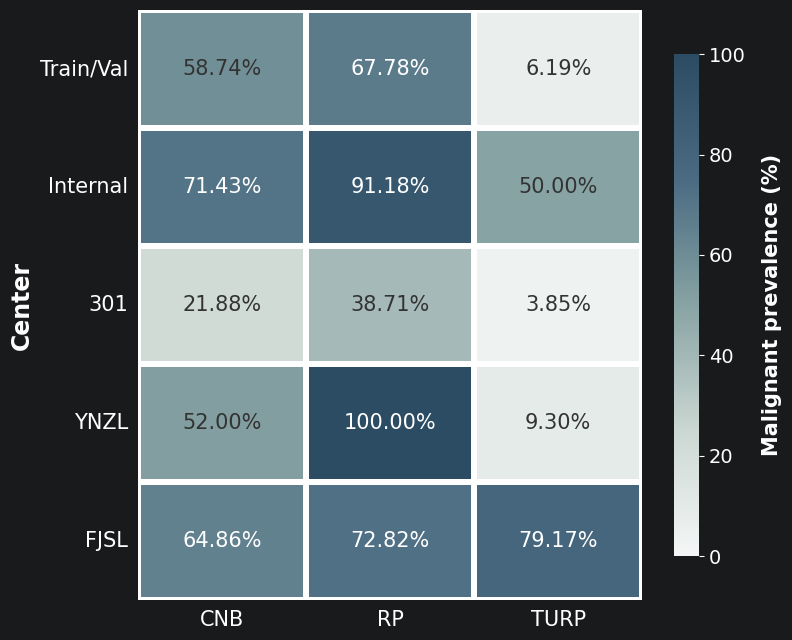

In [3]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. 数据准备与向量化计算

data = { "Center": ["Train/Val", "Internal", "301", "YNZL", "FJSL"], "CNB_B": [307, 14, 50, 24, 39], "CNB_M": [437, 35, 14, 26, 72], "RP_B": [319, 24, 19, 0, 28], "RP_M": [671, 248, 12, 43, 75], "TURP_B": [470, 12, 50, 39, 5], "TURP_M": [31, 12, 2, 4, 19], }

df = pd.DataFrame(data).set_index("Center")

# 一行高效计算比率与构建文本矩阵
heatmap_data = pd.DataFrame({t: (df[f"{t}_M"] / (df[f"{t}_M"] + df[f"{t}_B"]) * 100) for t in ["CNB", "RP", "TURP"]})
annot_array = heatmap_data.map(lambda x: f"{x:.2f}%").values

# 2. 统一大字号基准与高级莫兰迪色谱配置
FS = 15
cmap = mcolors.LinearSegmentedColormap.from_list("morandi", ["#F4F6F6", "#CBD7D2", "#87A3A3", "#4A6B82", "#2B4C63"])
text_colors = np.where(heatmap_data.values > 60, "#FFFFFF", "#333333").flatten()

# 3. 绘制热力图（修正：lc -> linecolor）
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(heatmap_data, annot=annot_array, fmt="", cmap=cmap, linewidths=3, linecolor="white", vmin=0, vmax=100, ax=ax, cbar_kws={"shrink": 0.85}, annot_kws={"size": 25, "weight": "bold"})

# 4. 细节美化与字号放大
for text, color in zip(ax.texts, text_colors):
    text.set(color=color, fontsize=FS, weight="medium", linespacing=1.3)

ax.tick_params(left=False, bottom=False, labelsize=FS, rotation=0)
# ax.set_ylabel("Center", fontsize=FS + 2, fontweight="semibold")

cbar = ax.collections[0].colorbar
cbar.set_label("Malignant prevalence (%)", fontsize=FS, fontweight="semibold", labelpad=12)
cbar.ax.tick_params(labelsize=FS - 1)

plt.tight_layout()
plt.savefig("cohort/Malignant.svg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data = {"Center": ["Train/Val", "Internal", "301", "YNZL", "FJSL"], "CNB_B": [307, 14, 50, 24, 39], "CNB_M": [437, 35, 14, 26, 72], "RP_B": [319, 24, 19, 0, 28], "RP_M": [671, 248, 12, 43, 75], "TURP_B": [470, 12, 50, 39, 5], "TURP_M": [31, 12, 2, 4, 19]}
df = pd.DataFrame(data).set_index("Center")

heatmap_data = pd.DataFrame({t: df[f"{t}_M"] / (df[f"{t}_M"] + df[f"{t}_B"]) * 100 for t in ["CNB", "RP", "TURP"]}).T
annot_array = heatmap_data.map(lambda x: f"{x:.2f}%").values

FS = 15
cmap = mcolors.LinearSegmentedColormap.from_list("morandi", ["#F4F6F6", "#CBD7D2", "#87A3A3", "#4A6B82", "#2B4C63"])
text_colors = np.where(heatmap_data.values > 60, "#FFFFFF", "#333333").flatten()

fig, ax = plt.subplots(figsize=(10, 6.7))
sns.heatmap(heatmap_data, annot=annot_array, fmt="", cmap=cmap, linewidths=3, linecolor="white", vmin=0, vmax=100, ax=ax, cbar=False, annot_kws={"size": FS + 3, "weight": "bold"})
for text, color in zip(ax.texts, text_colors):
    text.set(color=color, fontsize=FS + 10, weight="semibold")

ax.tick_params(left=False, bottom=False, labelsize=FS, rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Malignant prevalence (%)", fontsize=FS+4, fontweight="semibold", pad=20)


plt.tight_layout()
plt.savefig("cohort/Malignant.svg", dpi=300, bbox_inches="tight")
plt.show()